In [1]:
import torch
from transformers import AutoModelForSequenceClassification
from transformers import AutoTokenizer
import numpy as np
import pandas as pd
import os
import sys
import glob
import tqdm
import re
from typing import List
import matplotlib.pyplot as plt

sys.path.append("../../benchmark")
from sentence_splitter import split_text_into_sentences

/Users/hendrikweichel/miniconda3/envs/nace_project/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
sentence_length = 6

## Test using a BERT-Classification Model trained on paragraphs to classify an entire report.

**Function:** pdf -> NACE Class

In [3]:
%cd ~/work/projects/nace_classification/nace_report_topic_analysis/doc_search_and_BERT/Train_BERT/

[Errno 2] No such file or directory: '/Users/hendrikweichel/work/projects/nace_classification/nace_report_topic_analysis/doc_search_and_BERT/Train_BERT/'
/Users/hendrikweichel/projects/NaceCodeClassification/nace_report_topic_analysis_3/doc_search_and_BERT/Classify_report_with_BERT


In [4]:
%pwd

'/Users/hendrikweichel/projects/NaceCodeClassification/nace_report_topic_analysis_3/doc_search_and_BERT/Classify_report_with_BERT'

In [5]:
dataset_path = "../../data/datasets/german_annual_reports"
dataset_path = "../../data/datasets/stoxx_600_extended"
dataset_path = "../../data/datasets/reports_subset_from_full_data_1"
dataset_path = "../../data/datasets/stoxx_600"

In [6]:
over_view_df_path = os.path.join(dataset_path, os.path.basename(dataset_path) + "_overview.csv")

dataset_path_texts = os.path.join(dataset_path, "TXTs")

dataset_name = os.path.basename(dataset_path)

In [7]:
nace_classes = pd.read_csv(over_view_df_path, index_col=0, sep=";")
nace_classes.head()

,Name,Symbol,FactSet ID,Revenue - 2022 (in EUR),Revenue - 2023 (in EUR),Revenue - 2024 (in EUR),NACE,NACE_letter,Report,description_page
483,3i Group plc,III-GB,III-GB,701.210162,1276.962137,NaN,66.30,K,NaN,NaN
354,A.P. Moller - Maersk A/S Class B,MAERSK.B-DK,MAERSK.B-DK,77568.022858,47226.219381,51288.2262335699,50.20,H,NaN,NaN
275,A2A S.p.A.,A2A-IT,A2A-IT,22938.000000,14492.000000,NaN,35.11,D,NaN,NaN
107,AAK AB,AAK-SE,AAK-SE,4741.086317,4010.433824,3939.34280627966,10.89,C,AAK AB1.pdf,3
122,Aalberts N.V.,AALB-NL,AALB-NL,3230.000000,3324.000000,3148.6,25.93,C,Aalberts N.V.1.pdf,NaN


In [8]:
report_to_nace_class = nace_classes.dropna(subset=["Report"]).set_index('Report').to_dict()["NACE"]
report_to_nace_class = {report[0][:-4] + ".txt": report[1] for report in report_to_nace_class.items()}
len(report_to_nace_class)

291

In [9]:
reports_path = glob.glob(os.path.join(dataset_path_texts, "*.txt"))
len(reports_path)

263

In [10]:
def get_tables(lines: list): 
    tables = []
    current_table = []

    for line in lines:
        if line.strip().startswith("|"):  # line belongs to a table
            current_table.append(line.strip())
        else:
            if current_table:  # table ended
                tables.append("\n".join(current_table))
                current_table = []

    # catch last table if file ends without empty lines
    if current_table:
        tables.append("\n".join(current_table))

    return tables

def preprocess_report(pdf_path: str) -> List[str]:

    with open(pdf_path, "r") as f: 
        text = f.read()
    
    lines = text.split("\n")

    tables = get_tables(lines)

    # drop if condidtion is True
    conditions = [
        # filter images
        lambda line: line == '<!-- image -->',
        
        #filter tables 
        lambda line: (line[0] == "|" and line[-1] == "|") if len(line) > 1 else False, 

        # filter headers
        lambda line: line.strip()[0] == "#" if len(line) > 0 else True,

        # filter sentences
        lambda line: "." not in line,
        
        # more than 50% is numbers
        lambda line: sum(ch.isalpha() for ch in line) / len(line) < 0.5,

        # minimum 3 words 
        lambda line: len(re.sub(r"[^a-zA-ZäöüÄÖÜß\s]", '', line).strip().split(" ")) < 3,

        # Minimum 2 Sentences
        #lambda line: sum([0 if len(sentence.split(" ")) < 3 else 1 for sentence in split_text_into_sentences(line, "en")]) < 2

    ]
    accepted_lines = [line for line in lines if not any(condition(line) for condition in conditions)]
    accepted_lines += tables

    chunks = []

    for line in accepted_lines: 
        sentences = split_text_into_sentences(line, language='en')
        sentences = [sentence.strip() for sentence in sentences]
        sentences = [sentence for sentence in sentences if sentence != ""]
        new_chunks = [(" ".join(sentences[i:i+sentence_length])).strip() for i in range(0, len(sentences), 3)]

        chunks += new_chunks

    # if there is only one sentence in the last chunk, balance the two last chunks
    if len(split_text_into_sentences(chunks[-1], language = "en")) == 1: 
        last_two_chunks = chunks[-2] + " " + chunks[-1]
        chunks[-2] = last_two_chunks[0:(len(last_two_chunks) + 1) // 2]
        chunks[-1] = last_two_chunks[(len(last_two_chunks) + 1) // 2: (len(last_two_chunks)) - (len(last_two_chunks) + 1) // 2]

    chunks = [re.sub(r'\b\d+\.\d+\b', '', chunk) for chunk in chunks]
    chunks = [re.sub(r"[^a-zA-ZäöüÄÖÜß.\s]", '', chunk) for chunk in chunks]
    chunks = [re.sub(r"\s+", " ", chunk) for chunk in chunks]
    chunks = [re.sub(r'\.{2,}', " ", chunk) for chunk in chunks]
    chunks = [re.sub(r'^\d+\.\s*', " ", chunk) for chunk in chunks]
    chunks = [chunk.lower() for chunk in chunks]
    chunks = [chunk.strip() for chunk in chunks]

    return chunks

# Playground

In [11]:
chunks = preprocess_report(pdf_path=reports_path[0])
len(chunks)

359

In [12]:
model_path = "/Users/hendrikweichel/projects/NaceCodeClassification/nace_report_topic_analysis_3/doc_search_and_BERT/Train_BERT/results/results_null_classifiers__cos_thres_0.5__bert-base-uncased__train_full_model__some_labels/checkpoint-2331"

In [13]:
ckpt = model_path
final_dir = "my_model_final"  

model = AutoModelForSequenceClassification.from_pretrained(ckpt)
tokenizer = AutoTokenizer.from_pretrained(ckpt)

sentenec = "all manufacturing of secondary aluminium is defined by the taxonomy as making a substantial contribution to climate change mitigation. to be a taxonomyaligned activity the manufacture of secondary aluminium must also comply with the dnsh criteria for manufacture of aluminium and hydro must comply with the criteria for processes and outcomes related to human rights bribery and corruption taxation and fair competition minimum safeguards."
sentenec = "all manufacturing of secondary aluminium is defined by the taxonomy as making a substantial contribution to climate change mitigation. to be a taxonomyaligned activity the manufacture of secondary aluminium must also comply with the dnsh criteria for manufacture of aluminium and hydro must comply with the criteria for processes and outcomes related to human rights bribery and corruption taxation and fair competition minimum safeguards."
sentenec = "i. regasification basic and secondary transmission as well as storage of natural gas via the corresponding gas infrastructure or facilities of its own or of third parties and also the performance of auxiliary activities or others related to the aforementioned activities."
inputs = tokenizer(sentenec, return_tensors="pt")
with torch.no_grad():
    outputs = model(**inputs)
    logits = outputs.logits
    predictions = torch.argmax(logits, dim=-1)
logits
# If you set id2label in config earlier, you can get human-readable labels
label = model.config.id2label[predictions.item()]
print("Predicted label:", label)

Some weights of the model checkpoint at /Users/hendrikweichel/projects/NaceCodeClassification/nace_report_topic_analysis_3/doc_search_and_BERT/Train_BERT/results/results_null_classifiers__cos_thres_0.5__bert-base-uncased__train_full_model__some_labels/checkpoint-2331 were not used when initializing BertForSequenceClassification: ['classifier.0.bias', 'classifier.0.weight', 'classifier.3.bias', 'classifier.3.weight']
- This IS expected if you are initializing BertForSequenceClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForSequenceClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Some weights of BertForSequenceClassification were not initialized from the model check

Predicted label: P


In [14]:
# import torch
# from transformers import AutoModelForSequenceClassification, AutoTokenizer

# def load_model(ckpt_path: str):
#     """
#     Loads a fine-tuned NACE BERT classifier and tokenizer from a checkpoint path.
#     Automatically places model on GPU if available.
    
#     Returns:
#         model      -- the loaded classifier (in eval mode)
#         tokenizer  -- matching tokenizer
#         device     -- torch.device("cuda") or torch.device("cpu")
#     """
#     # Load
#     model = AutoModelForSequenceClassification.from_pretrained(ckpt_path)
#     tokenizer = AutoTokenizer.from_pretrained(ckpt_path)
    
#     # Device
#     if torch.cuda.is_available():
#         device = torch.device("cuda")
#     # elif torch.backends.mps.is_available():
#     #     device = torch.device("mps")
#     else:
#         device = torch.device("cpu")
#     model.to(device)
#     model.eval()

#     return model, tokenizer, device

In [15]:
# model, tokenizer, device = load_model(ckpt)

In [16]:
model.eval()
chunk_logits = []   
sentence_classification = []

with torch.no_grad():
    for chunk in ["This section includes financial service activities, including insurance, reinsurance and pension funding activities and activities to support financial services."]:

        inputs = tokenizer(
            chunk,
            return_tensors="pt",
            truncation=True,
            padding=True,
            max_length=512,
        )
        
        outputs = model(**inputs)
        # shape: (1, num_labels) -> (num_labels,)
        logits = outputs.logits.squeeze(0)
        chunk_logits.append(logits)

    label_scores = {
        model.config.id2label[i]: logits[i].item()
        for i in range(logits.size(0))
    }
    sentence_classification.append(label_scores)

In [17]:
df_label_scores = pd.DataFrame.from_dict(label_scores, orient="index")
df_label_scores

,0
F,0.265274
P,-1.150189
L,0.379089
K,0.548668
I,0.221663
A,-0.134706
D,0.215958
G,-0.721877
E,-0.475341
NO_CLASS,0.177942


In [18]:
df_label_scores = df_label_scores.sort_values(0, ascending=False)

In [19]:
df_label_scores

,0
Q,0.903257
J,0.784315
N,0.771571
M,0.636591
K,0.548668
C,0.458841
L,0.379089
F,0.265274
I,0.221663
D,0.215958


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16],
 [Text(0, 0, 'Q'),
  Text(1, 0, 'J'),
  Text(2, 0, 'N'),
  Text(3, 0, 'M'),
  Text(4, 0, 'K'),
  Text(5, 0, 'C'),
  Text(6, 0, 'L'),
  Text(7, 0, 'F'),
  Text(8, 0, 'I'),
  Text(9, 0, 'D'),
  Text(10, 0, 'H'),
  Text(11, 0, 'NO_CLASS'),
  Text(12, 0, 'A'),
  Text(13, 0, 'B'),
  Text(14, 0, 'E'),
  Text(15, 0, 'G'),
  Text(16, 0, 'P')])

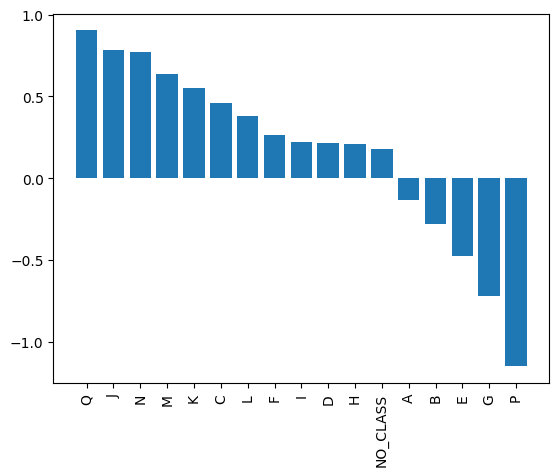

In [20]:
plt.bar(df_label_scores.index, df_label_scores[0])
plt.xticks(rotation=90)

In [21]:
def classification_report_BERT(chunks: list, 
                    model: AutoModelForSequenceClassification,
                    tokenizer: AutoTokenizer,
                    result_path: str,
                    report_path: str, 
                    level: int = None,
                    **kwags) -> dict:
    """
    1. Preprocess a report into text chunks.
    2. Classify each chunk with the BERT model.
    3. Aggregate logits over all chunks and return {label: logit_score}.
    """

    # 1) Preprocess report -> list of chunks
    chunks = [chunk for chunk in chunks if chunk.strip()]

    # Safety: no chunks -> empty result
    if len(chunks) == 0:
        return {}

    model.eval()
    chunk_logits = []   
    sentence_classification = []

    # 2) Classify each chunk
    with torch.no_grad():
        for chunk in chunks:

            inputs = tokenizer(
                chunk,
                return_tensors="pt",
                truncation=True,
                padding=True,
                max_length=512,
            )
            outputs = model(**inputs)
            # shape: (1, num_labels) -> (num_labels,)
            logits = outputs.logits.squeeze(0)
            chunk_logits.append(logits)

            label_scores = {
                model.config.id2label[i]: logits[i].item()
                for i in range(logits.size(0))
            }
            sentence_classification.append(label_scores)

    if len(chunk_logits) == 0:
        return {}
    
    # 3) Aggregate logits over all chunks (mean over chunks)
    stacked = torch.stack(chunk_logits, dim=0)  # (num_chunks, num_labels)
    avg_logits = stacked.mean(dim=0)            # (num_labels,)

    # Map to human-readable labels
    label_scores = {
        model.config.id2label[i]: avg_logits[i].item()
        for i in range(avg_logits.size(0))
    }

    sentence_classification = pd.DataFrame(sentence_classification)
    sentence_classification["Sentences"] = chunks

    os.makedirs(os.path.join(result_path, os.path.basename(report_path)), exist_ok=True)
    sentence_classification.to_csv(os.path.join(result_path, os.path.basename(report_path), os.path.basename(report_path) + "_classifications.csv"))

    #return pd.DataFrame.from_dict(label_scores, orient="index")[0]
    return label_scores


In [22]:
def classify_report(chunks: list, 
                    model: AutoModelForSequenceClassification,
                    tokenizer: AutoTokenizer,
                    result_path: str,
                    level: int = None,
                    **kwags) -> dict:
    """
    1. Preprocess a report into text chunks.
    2. Classify each chunk with the BERT model.
    3. Aggregate logits over all chunks and return {label: logit_score}.
    """

    # 1) Preprocess report -> list of chunks
    chunks = [chunk for chunk in chunks if chunk.strip()]

    # Safety: no chunks -> empty result
    if len(chunks) == 0:
        return {}

    model.eval()
    chunk_logits = []   
    sentence_classification = []

    # 2) Classify each chunk
    with torch.no_grad():
        for chunk in chunks:

            inputs = tokenizer(
                chunk,
                return_tensors="pt",
                truncation=True,
                padding=True,
                max_length=512,
            )
            outputs = model(**inputs)
            # shape: (1, num_labels) -> (num_labels,)
            logits = outputs.logits.squeeze(0)
            chunk_logits.append(logits)

            label_scores = {
                model.config.id2label[i]: logits[i].item()
                for i in range(logits.size(0))
            }
            sentence_classification.append(label_scores)

    if len(chunk_logits) == 0:
        return {}
    
    print(len(chunk_logits))

    # 3) Aggregate logits over all chunks (mean over chunks)
    stacked = torch.stack(chunk_logits, dim=0)  # (num_chunks, num_labels)
    avg_logits = stacked.mean(dim=0)            # (num_labels,)

    # Map to human-readable labels
    label_scores = {
        model.config.id2label[i]: avg_logits[i].item()
        for i in range(avg_logits.size(0))
    }

    sentence_classification = pd.DataFrame(sentence_classification)
    sentence_classification["Sentences"] = chunks

    os.makedirs(os.path.join(result_path, os.path.basename(report_path)), exist_ok=True)
    sentence_classification.to_csv(os.path.join(result_path, os.path.basename(report_path), os.path.basename(report_path) + "_classifications.csv"))

    return label_scores, sentence_classification

In [23]:
def classify_report_1(report_path: str,
                    model: AutoModelForSequenceClassification,
                    tokenizer: AutoTokenizer) -> dict:
    """
    1. Preprocess a report into text chunks.
    2. Classify each chunk with the BERT model.
    3. Aggregate logits over all chunks and return {label: logit_score}.
    """

    # 1) Preprocess report -> list of chunks
    chunks = preprocess_report(pdf_path=report_path)

    # Safety: no chunks -> empty result
    if len(chunks) == 0:
        return {}

    model.eval()
    chunk_logits = []

    # 2) Classify each chunk
    with torch.no_grad():
        for chunk in chunks:
            if not chunk.strip():
                continue

            inputs = tokenizer(
                chunk,
                return_tensors="pt",
                truncation=True,
                padding=True,
                max_length=512,
            )
            outputs = model(**inputs)
            # shape: (1, num_labels) -> (num_labels,)
            logits = outputs.logits.squeeze(0)
            chunk_logits.append(logits)

    if len(chunk_logits) == 0:
        return {}

    # 3) Aggregate logits over all chunks (mean over chunks)
    stacked = torch.stack(chunk_logits, dim=0)  # (num_chunks, num_labels)
    avg_logits = stacked.mean(dim=0)            # (num_labels,)

    # Map to human-readable labels
    label_scores = {
        model.config.id2label[i]: avg_logits[i].item()
        for i in range(avg_logits.size(0))
    }

    return label_scores

In [24]:
report_path = reports_path[0]
report_path

'../../data/datasets/stoxx_600/TXTs/Hannover Rueck SE1.txt'

In [25]:
classify_report_1(report_path, model, tokenizer)

{'F': -0.18976379930973053,
 'P': -0.09544174373149872,
 'L': -0.29598870873451233,
 'K': -0.09442056715488434,
 'I': 0.29487812519073486,
 'A': 0.2215467095375061,
 'D': 0.42171698808670044,
 'G': -0.9674521684646606,
 'E': 0.28601357340812683,
 'NO_CLASS': 0.321013867855072,
 'B': -0.059223517775535583,
 'J': -0.2626137435436249,
 'H': 0.2623905539512634,
 'Q': 0.38740649819374084,
 'M': 0.47924745082855225,
 'N': 0.22566363215446472,
 'C': 0.3322443664073944}

In [26]:
chunks = preprocess_report(pdf_path=report_path)   

# Example usage on the first report:
report_scores = classification_report_BERT(chunks, model, tokenizer, result_path="../../results/BERT_classification/test_1", report_path=report_path)
print(report_scores)

{'F': -0.18976379930973053, 'P': -0.09544174373149872, 'L': -0.29598870873451233, 'K': -0.09442056715488434, 'I': 0.29487812519073486, 'A': 0.2215467095375061, 'D': 0.42171698808670044, 'G': -0.9674521684646606, 'E': 0.28601357340812683, 'NO_CLASS': 0.321013867855072, 'B': -0.059223517775535583, 'J': -0.2626137435436249, 'H': 0.2623905539512634, 'Q': 0.38740649819374084, 'M': 0.47924745082855225, 'N': 0.22566363215446472, 'C': 0.3322443664073944}


In [27]:
chunks = preprocess_report(pdf_path=report_path)   

# Example usage on the first report:
report_scores, sentence_classification = classify_report(chunks, model, tokenizer, result_path="../../results/BERT_classification/test_1")
print(report_scores)

358
{'F': -0.18976379930973053, 'P': -0.09544174373149872, 'L': -0.29598870873451233, 'K': -0.09442056715488434, 'I': 0.29487812519073486, 'A': 0.2215467095375061, 'D': 0.42171698808670044, 'G': -0.9674521684646606, 'E': 0.28601357340812683, 'NO_CLASS': 0.321013867855072, 'B': -0.059223517775535583, 'J': -0.2626137435436249, 'H': 0.2623905539512634, 'Q': 0.38740649819374084, 'M': 0.47924745082855225, 'N': 0.22566363215446472, 'C': 0.3322443664073944}


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16],
 [Text(0, 0, 'F'),
  Text(1, 0, 'P'),
  Text(2, 0, 'L'),
  Text(3, 0, 'K'),
  Text(4, 0, 'I'),
  Text(5, 0, 'A'),
  Text(6, 0, 'D'),
  Text(7, 0, 'G'),
  Text(8, 0, 'E'),
  Text(9, 0, 'NO_CLASS'),
  Text(10, 0, 'B'),
  Text(11, 0, 'J'),
  Text(12, 0, 'H'),
  Text(13, 0, 'Q'),
  Text(14, 0, 'M'),
  Text(15, 0, 'N'),
  Text(16, 0, 'C')])

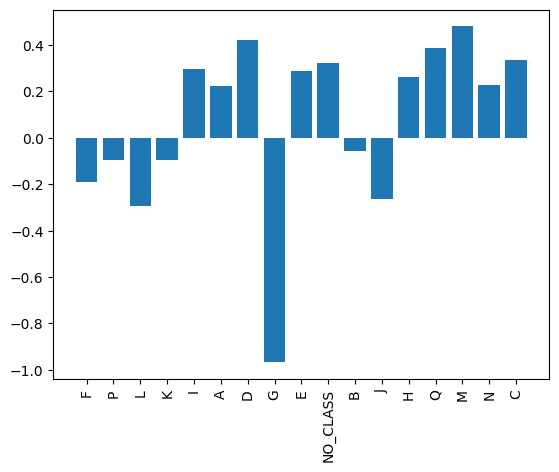

In [28]:
plt.bar(report_scores.keys(), report_scores.values())
plt.xticks(rotation=90)

In [29]:
sentence_classification


,F,P,L,K,I,A,D,G,E,NO_CLASS,B,J,H,Q,M,N,C,Sentences
0,-0.352704,0.040203,-0.513088,-0.334522,0.326270,0.308740,0.543419,-1.084684,0.446957,0.405469,-0.007274,-0.419192,0.370583,0.345423,0.479266,0.108381,0.315769,chairman of the board of directors hannover re...
1,-0.347752,0.024040,-0.511006,-0.334329,0.326696,0.305761,0.544456,-1.101374,0.446553,0.403924,-0.031818,-0.422320,0.363702,0.338779,0.482206,0.124348,0.331135,member of the board of directors hannover life...
2,-0.346379,0.056151,-0.516697,-0.358502,0.318715,0.313006,0.511211,-1.081811,0.458748,0.417730,0.014462,-0.414161,0.390717,0.362353,0.503768,0.095670,0.293595,chairman of the board of directors argenta hol...
3,-0.338883,0.048681,-0.495161,-0.358126,0.319266,0.305675,0.503423,-1.099289,0.445872,0.412493,-0.013169,-0.420396,0.379317,0.352926,0.501870,0.108275,0.309499,chairman of the board of directors hannover re...
4,-0.349153,0.040756,-0.519781,-0.348804,0.320995,0.317520,0.527385,-1.082559,0.452179,0.417266,0.006571,-0.421780,0.378154,0.361386,0.500095,0.097540,0.305000,chairman of the board of directors hannover fi...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
353,-0.300759,0.085303,-0.561600,-0.384821,0.284998,0.307335,0.437178,-1.056007,0.448177,0.410572,0.070070,-0.391600,0.354111,0.369418,0.502416,0.047312,0.224481,rück se with effect from january thereby expan...
354,-0.354948,0.047628,-0.480409,-0.322293,0.332727,0.313304,0.532814,-1.107565,0.415715,0.378363,-0.017409,-0.446344,0.395613,0.339283,0.497216,0.117956,0.349382,ms. ooi will be responsible for property and c...
355,-0.338701,0.087360,-0.563039,-0.362745,0.308707,0.305107,0.458427,-1.054520,0.458394,0.441423,0.064882,-0.407890,0.339877,0.378808,0.506538,0.058357,0.219677,thanks to the extraordinary performance and pr...
356,-0.317325,0.120972,-0.582555,-0.390845,0.274909,0.315858,0.414892,-1.048756,0.448335,0.454569,0.083232,-0.378538,0.364704,0.354132,0.552145,0.024577,0.229535,the supervisory board would like to express it...


In [30]:
df = sentence_classification.copy()
df_without = df.drop(columns=["Sentences"])
df_without.max(axis=1)

0      0.543419
1      0.544456
2      0.511211
3      0.503423
4      0.527385
         ...   
353    0.502416
354    0.532814
355    0.506538
356    0.552145
357    0.524679
Length: 358, dtype: float64

In [31]:
df_without = df_without[df_without["NO_CLASS"] != df_without.max(axis=1)]

In [32]:
for i, row in df_without.iterrows(): 
    print(row.idxmax())

D
D
D
D
D
D
D
D
D
D
M
D
D
M
M
M
M
Q
B
M
E
M
B
Q
M
G
M
D
B
D
D
C
H
M
M
B
M
D
M
M
M
E
D
D
M
M
D
N
F
N
N
Q
Q
Q
Q
M
Q
M
M
M
Q
D
Q
Q
D
D
D
D
D
M
Q
E
P
M
M
M
M
D
M
M
M
D
N
M
D
D
D
N
M
D
D
M
I
D
D
D
M
M
M
Q
D
M
M
M
M
M
Q
M
D
E
M
D
D
M
E
D
F
Q
M
Q
M
D
M
M
M
C
D
M
D
M
D
M
M
M
D
M
M
M
M
D
D
N
D
M
D
M
D
M
D
D
D
D
M
D
D
D
D
M
D
M
M
D
M
M
M
M
D
D
M
M
M
D
D
D
D
D
M
M
M
D
D
D
D
D
M
M
N
D
D
D
M
M
M
D
D
D
M
D
M
D
N
Q
E
N
I
M
M
Q
Q
M
D
D
D
D
D
D
M
Q
Q
M
M
M
M
M
D
D
M
F
D
Q
M
D
E
Q
D
D
M
M
N
M
D
E
N
N
I
D
D
M
M
M
D
N
D
D
M
Q
N
D
M
D
M
D
P
N
M
N
D
D
M
M
M
D
B
M
N
M
D
D
M
M
M
D
D
M
M
D
D
M
D
M
M
M
D
D
D
M
M
M
M
D
D
M
M
B
M
N
M
M
M
D
D
C
M
Q
D
M
B
D
D
M
M
M
D
D
D
D
D
D
D
D
D
D
M
M
D
D
D
D
M
D
M
M
M
M
D
M
M
M
